In [39]:
import pandas as pd

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import urllib.request
import io
sns.set_style('whitegrid')

url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
response = urllib.request.urlopen(url)
df = pd.read_csv(io.StringIO(response.read().decode('utf-8')))
print(f"✓ Dataset loaded — {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


✓ Dataset loaded — 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [41]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [43]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [44]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors ='coerce')

In [45]:
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors ='coerce')

In [46]:
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [47]:
df.dropna(inplace = True)

In [48]:
print(df.shape)

(7032, 21)


In [49]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

## Insight 1 — Churn Overview
26.5% of customers have churned. This means roughly 1 in 4 customers 
is leaving — a significant revenue risk for the business.

In [50]:
df.groupby("Contract")['Churn'].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1306
                Yes       166
Two year        No       1637
                Yes        48
Name: count, dtype: int64

## Insight 2 — Churn by Contract Type

- Month-to-month customers churn at 42% vs only 3% for two-year contracts
- Two-year customers show loyalty and higher satisfaction
- Recommendation: incentivise month-to-month customers to upgrade 
  to longer contracts through discounts or added benefits

In [51]:
plt.figure(figsize=(8,4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

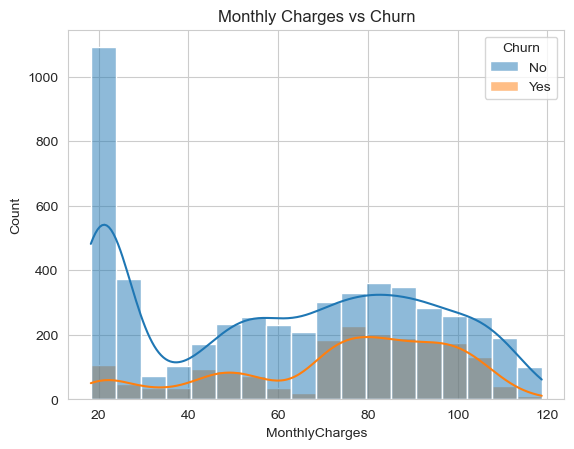

In [52]:
sns.histplot(x= "MonthlyCharges",
             hue = "Churn", data = df,
            kde = True)  ## KDE is Kernel Density Estimate use to draw a smooth curve onto top of bars
plt.title('Monthly Charges vs Churn')
plt.show()

## Insight 3 — Monthly Charges vs Churn

Customers with higher monthly charges churn more.
The churn curve peaks around ₹75-80 while retained 
customers mostly pay around ₹20.

Recommendation: Review pricing strategy for high-charge 
customers — consider loyalty discounts to retain them.

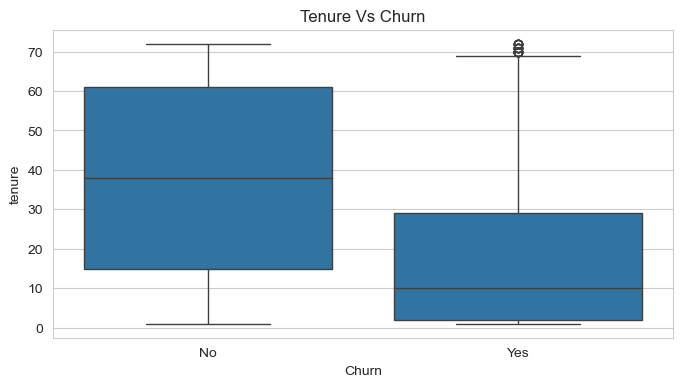

In [53]:
plt.figure(figsize=(8,4))
sns.boxplot(x ="Churn", y ="tenure",
            data = df)
plt.title("Tenure Vs Churn")
plt.show()

## Insight 4 — Tenure vs Churn

Churned customers have a median tenure of only 10 months
vs 37 months for retained customers.

The first 10 months are the highest risk period for churn.

Recommendation: Focus retention efforts on new customers
in their first year — onboarding experience, early 
loyalty rewards, and proactive support are critical.

Note: A few outliers show even 70+ month customers 
can churn — no customer should be taken for granted.

In [54]:
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
churn_rate = df.groupby('InternetService')['Churn_binary'].mean() * 100
print(churn_rate.round(2))

InternetService
DSL            19.00
Fiber optic    41.89
No              7.43
Name: Churn_binary, dtype: float64


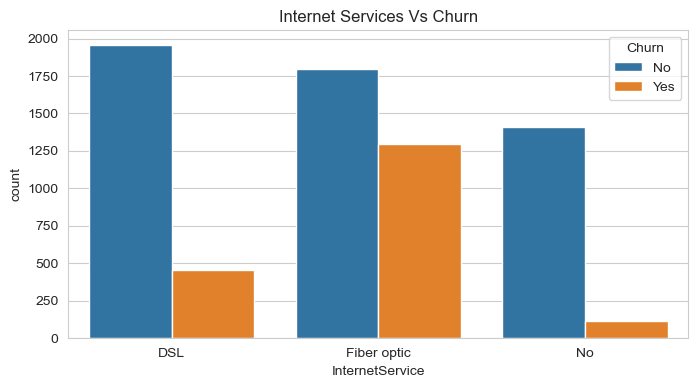

In [55]:
plt.figure(figsize=(8,4))
sns.countplot(x = 'InternetService',
              data = df, hue = "Churn")
plt.title("Internet Services Vs Churn")
plt.show()

## Insight 5 — Internet Service vs Churn

Fibre optic customers churn at 42% — the highest of 
all internet service types. Combined with higher monthly 
charges, fibre optic is the highest risk segment.

Recommendation: Investigate fibre optic service quality 
and pricing — customers may not feel the value matches 
the cost.

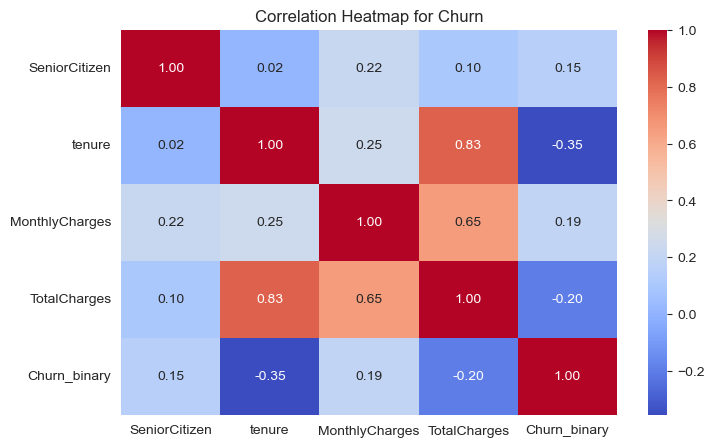

In [56]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, 
            fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap for Churn')
plt.show()

## Insight 6 — Correlation Heatmap

Key relationships with Churn:
- tenure (-0.35) — strongest predictor. 
  Longer customers churn less.
- TotalCharges (-0.20) — negative, longer 
  customers pay more overall and stay longer.
- MonthlyCharges (0.19) — positive, higher 
  charges = more churn.
- SeniorCitizen (0.15) — seniors churn slightly more.

Conclusion: tenure and MonthlyCharges are the 
most important features for our ML model.

In [57]:
df.select_dtypes(include="object").columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [58]:
df.drop(columns ="customerID", inplace = True)

In [59]:
y = df['Churn'].map({'Yes': 1, 'No': 0})
print(y.value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [60]:
df.drop(columns=['Churn'], inplace=True)

In [61]:
df.drop(columns=['Churn_binary'], inplace=True)

In [62]:
binary_cols = ['gender', 'Partner', 'Dependents', 
               'PhoneService', 'PaperlessBilling']

df[binary_cols] = df[binary_cols].apply(lambda x: x.map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}))


In [63]:
df[binary_cols].head()


,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,1
3,1,0,0,0,0
4,0,0,0,1,1


In [89]:
df =pd.get_dummies(df, drop_first = True, dtype = "int")

In [90]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,1,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,1,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,0,...,0,0,0,0,0,0,0,0,1,0


In [66]:
print(df.shape)
print(y.shape)


(7032, 30)
(7032,)


In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X_train, X_test, y_train, y_test = train_test_split(df , y ,test_size = 0.2 , random_state=42)

In [69]:
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 5625
Testing rows: 1407


In [70]:
from sklearn.linear_model import LogisticRegression

In [71]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [72]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
reg = LogisticRegression(max_iter =1000)

In [74]:
model =reg.fit(X_train_scaled,y_train)

In [82]:
y_pred = reg.predict(X_test_scaled)

In [83]:
from sklearn.metrics import accuracy_score

In [84]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7874911158493249


In [91]:
from sklearn.metrics import confusion_matrix, classification_report

In [92]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))

[[915 118]
 [181 193]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [98]:
from sklearn.ensemble import RandomForestClassifier

In [99]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [100]:
rf.fit(X_train_scaled,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [101]:
y_pred_rf = rf.predict(X_test_scaled)

In [102]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.7867803837953091


In [103]:
print(confusion_matrix(y_test,y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[934  99]
 [201 173]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.64      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



In [105]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7739872068230277


In [106]:
print(confusion_matrix(y_test,y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

[[903 130]
 [188 186]]
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.50      0.54       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.69      1407
weighted avg       0.76      0.77      0.77      1407



In [107]:
churn_prob = reg.predict_proba(X_test_scaled)
print(churn_prob[:5])

[[0.99424589 0.00575411]
 [0.87395582 0.12604418]
 [0.31881283 0.68118717]
 [0.8825674  0.1174326 ]
 [0.64083298 0.35916702]]


In [108]:
churn_prob_only = churn_prob[:, 1]

In [109]:
print(churn_prob_only)

[0.00575411 0.12604418 0.68118717 ... 0.09609863 0.26400179 0.00215415]


In [111]:
conditions = [
    churn_prob_only >= 0.7,
    (churn_prob_only >= 0.3) & (churn_prob_only < 0.7),
    churn_prob_only < 0.3
]

choices = ['High Risk', 'Medium Risk', 'Low Risk']

risk_tier = np.select(conditions, choices,default='Unknown')
print(pd.Series(risk_tier).value_counts())

Low Risk       863
Medium Risk    442
High Risk      102
Name: count, dtype: int64


In [112]:
results = pd.DataFrame({
    'Churn_Probability': churn_prob_only,
    'Risk_Tier': risk_tier,
    'Actual_Churn': y_test.values
})

print(results.head(10))

   Churn_Probability    Risk_Tier  Actual_Churn
0           0.005754     Low Risk             0
1           0.126044     Low Risk             0
2           0.681187  Medium Risk             1
3           0.117433     Low Risk             0
4           0.359167  Medium Risk             0
5           0.443508  Medium Risk             0
6           0.128571     Low Risk             0
7           0.752234    High Risk             0
8           0.218011     Low Risk             0
9           0.017956     Low Risk             0


In [117]:
results['MonthlyCharges'] = X_test['MonthlyCharges'].values
results['Revenue_at_Risk'] = results['Churn_Probability'] * results['MonthlyCharges']

In [118]:
results.head(10)

,Churn_Probability,Risk_Tier,Actual_Churn,MonthlyCharges,Revenue_at_Risk
0,0.005754,Low Risk,0,25.00,0.143853
1,0.126044,Low Risk,0,24.70,3.113291
2,0.681187,Medium Risk,1,102.25,69.651388
3,0.117433,Low Risk,0,55.05,6.464665
4,0.359167,Medium Risk,0,29.45,10.577469
5,0.443508,Medium Risk,0,29.80,13.216538
6,0.128571,Low Risk,0,80.85,10.394933
7,0.752234,High Risk,0,91.50,68.829447
8,0.218011,Low Risk,0,69.50,15.151780
9,0.017956,Low Risk,0,85.25,1.530745


In [120]:
print("Total revenue at risk: ₹", round(results['Revenue_at_Risk'].sum(), 2))

Total revenue at risk: ₹ 28145.87


In [121]:
print(results.groupby('Risk_Tier')['Revenue_at_Risk'].sum().round(2))

Risk_Tier
High Risk       6515.86
Low Risk        5290.62
Medium Risk    16339.39
Name: Revenue_at_Risk, dtype: float64


## Phase 4 — Risk Scoring Results

Total revenue at risk per month: ₹28,145
Annualised risk: ₹3,37,740

By tier:
- High Risk (102 customers)   → ₹6,515/month
- Medium Risk (442 customers) → ₹16,339/month  
- Low Risk (863 customers)    → ₹5,290/month

Key insight: Medium risk segment carries the highest
total revenue risk due to volume — cannot be ignored!